# RBM Data Preparation

Prepare MovieLens ratings for RBM training with the following preprocessing pipeline:

Split ratings into training and testing sets.

Convert the training set into a user-movie rating matrix.

Select 2,000 users to form the working matrix for computation.

Convert ratings into binary RBM visible units.

Embed the binary visible units as hyperbolic numbers.


ratings  
→ train/test split  
→ user-movie matrix  
→ binary RBM visible units  
→ hyperbolic-number embedding  
→ inspection of embedded variables

The hyperbolic embedding step is based only on the paper *Hyperbolic Hopfield Neural Networks*.

### Binary → Hyperbolic embedding of RBM visible units

After converting MovieLens ratings into binary visible units

$$
v_{ij} \in \{0,1\}
$$

each visible unit is embedded as a **hyperbolic number**

$$
z = x + u y
$$

where \(u^2 = 1\).

To ensure that all neuron states lie on the **unit hyperbola**

$$
x^2 - y^2 = 1
$$

we use the exponential form of hyperbolic numbers (Eq. 18 of the paper):

$$
\exp(u t) = \cosh(t) + u\sinh(t)
$$

Therefore, each binary value is mapped to a point on the hyperbolic unit curve:

$$
z =
\begin{cases}
\cosh(t_0) + u\sinh(t_0), & v = 1 \\
\cosh(t_0) - u\sinh(t_0), & v = 0
\end{cases}
$$

This creates two symmetric states on the hyperbolic curve \(S\).

### Numerical values used in the implementation

The notebook uses the parameter \(t_0 = 0.8\).

Using the definitions of hyperbolic cosine and sine

$$
\cosh(t) = \frac{e^t + e^{-t}}{2}
$$

$$
\sinh(t) = \frac{e^t - e^{-t}}{2}
$$

we obtain

$$
\cosh(0.8) =
\frac{e^{0.8} + e^{-0.8}}{2}
\approx 1.337435
$$

$$
\sinh(0.8) =
\frac{e^{0.8} - e^{-0.8}}{2}
\approx 0.888106
$$

Thus each binary visible unit becomes a hyperbolic number

$$
z = 1.337435 + u(\pm 0.888106)
$$

which satisfies

$$
x^2 - y^2 = 1
$$

ensuring the embedding lies on the hyperbolic unit curve \(S\).

This step converts the binary RBM visible layer into hyperbolic-valued neuron states, preparing the data for the hyperbolic activation function \(g(z) = z / |z|\) defined in Eq. (34).

## Formulas used in this preprocessing step

Hyperbolic-number representation (Eq. (12)–(15)):

$$
z = x + uy
$$

Valid domain (Eq. (16)):

$$
D = \{ z = x + uy \in H \; ; \; x > 0,\ x^2 > y^2 \}
$$

Unit hyperbola (Eq. (17)):

$$
S = \{ z \in D \; ; \; |z| = 1 \}
$$

Hyperbolic exponential form (Eq. (18)):

$$
\exp(ut) = \cosh(t) + u\sinh(t)
$$

Hyperbolic activation (Eq. (34)):

$$
g(z) = \frac{z}{|z|}
$$

In this notebook, binary visible units are embedded onto the unit hyperbola using Eq. (18), so they are prepared for the hyperbolic activation defined in Eq. (34).

**Note**: The full MovieLens-20M ratings can be too large for a pivot table on many laptops. Use the limits below to avoid kernel crashes, then increase gradually if needed.

## Step 1 — Train/Test Split (chronological)

Requirements:
- Use `rating.csv` (fallback: `ratings.csv`).
- Convert `timestamp` to datetime.
- Sort by time and split 80% train / 20% test.
- Ensure test only contains users and movies seen in training.


In [26]:
import os
from pathlib import Path
import pandas as pd

# Resolve project root regardless of where the notebook runs
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

data_dir = project_root / "data"

ratings_path = data_dir / "rating.csv"
if not ratings_path.exists():
    ratings_path = data_dir / "ratings.csv"

if not ratings_path.exists():
    raise FileNotFoundError("rating.csv (or ratings.csv) not found")

# Step 1 — Chronological Train/Test Split
ratings = pd.read_csv(ratings_path)
ratings["timestamp"] = pd.to_datetime(ratings["timestamp"], errors="coerce")
print("timestamp NaT count:", ratings["timestamp"].isna().sum())
ratings = ratings.dropna(subset=["timestamp"]).copy()
ratings = ratings.sort_values("timestamp").reset_index(drop=True)

split_idx = int(len(ratings) * 0.8)
train_ratings = ratings.iloc[:split_idx].copy()
test_ratings = ratings.iloc[split_idx:].copy()

# Step 2 — Filter Test Users Only (no movie filtering)
train_users = set(train_ratings["userId"].unique())
test_ratings = test_ratings[
    test_ratings["userId"].isin(train_users)
].copy()

# Step 3 — Print Dataset Statistics
print("train_ratings.shape:", train_ratings.shape)
print("test_ratings.shape:", test_ratings.shape)

print("train users:", train_ratings["userId"].nunique())
print("train movies:", train_ratings["movieId"].nunique())

print("test users:", test_ratings["userId"].nunique())
print("test movies:", test_ratings["movieId"].nunique())

# Step 4 — Print the Chronological Split Time
split_time = ratings.iloc[split_idx]["timestamp"]
print("================================")
print("Train/Test split timestamp:", split_time)
print("train max time:", train_ratings["timestamp"].max())
print("test min time:", test_ratings["timestamp"].min())
print("================================")

# Step 5 — Save the Results
output_dir = data_dir / "processed"
output_dir.mkdir(parents=True, exist_ok=True)
train_ratings.to_csv(output_dir / "train_ratings.csv", index=False)
test_ratings.to_csv(output_dir / "test_ratings.csv", index=False)
print("Saved splits to:", output_dir)


timestamp NaT count: 0
train_ratings.shape: (16000210, 4)
test_ratings.shape: (739053, 4)
train users: 112466
train movies: 12388
test users: 5643
test movies: 23012
Train/Test split timestamp: 2009-10-20 07:33:43
train max time: 2009-10-20 07:33:38
test min time: 2009-10-20 07:33:43
Saved splits to: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/data/processed


## Step 2 — Build and Save User × Movie Matrix

Use the training subset to build the user–movie matrix with `pivot_table`, inspect its shape, preview a few rows, and save it to `data/processed/`.

In [27]:
# Build user–movie matrix from subset
# Limit dataset size before pivoting
MAX_USERS = 2000
MAX_MOVIES = 4000

# Select first MAX_USERS users from training
first_users = train_ratings["userId"].drop_duplicates().head(MAX_USERS)
train_subset = train_ratings[train_ratings["userId"].isin(first_users)].copy()

# From that subset, select top MAX_MOVIES movies by rating count
top_movies = train_subset["movieId"].value_counts().head(MAX_MOVIES).index
train_subset = train_subset[train_subset["movieId"].isin(top_movies)].copy()

print("about to pivot training subset...")
print("train_subset.shape:", train_subset.shape)
print("subset users:", train_subset["userId"].nunique())
print("subset movies:", train_subset["movieId"].nunique())

user_movie_matrix = train_subset.pivot_table(
    index="userId",
    columns="movieId",
    values="rating",
    aggfunc="mean"
)

print("user_movie_matrix.shape:", user_movie_matrix.shape)
print("user_movie_matrix preview (first 5 rows × 8 cols):")

# Keep display small to avoid overlapping outputs
pd.set_option("display.max_columns", 8)
pd.set_option("display.width", 120)

display(user_movie_matrix.iloc[:5, :8])

user_movie_matrix.to_csv(output_dir / "user_movie_matrix_train.csv")
print("Saved matrix to:", output_dir / "user_movie_matrix_train.csv")


about to pivot training subset...
train_subset.shape: (112193, 4)
subset users: 2000
subset movies: 1320
user_movie_matrix.shape: (2000, 1320)
user_movie_matrix preview (first 5 rows × 8 cols):


movieId,1,2,3,4,5,6,7,8
userId,,,,,,,,
68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
224,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
452,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN


Saved matrix to: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/data/processed/user_movie_matrix_train.csv


## Hyperbolic embedding of visible units

MovieLens ratings are **not** mapped directly to hyperbolic numbers. The transformation is:

ratings → binary RBM visible units \(v_i \in \{0,1\}\) → hyperbolic numbers \(z_i = x_i + u y_i\) (Eq. (12)–(15)).

For a chosen scalar \(t_0\), we embed each binary state using the hyperbolic exponential form (Eq. (18)):

If \(v_i = 1\):

$$
z_i = \exp(u t_0) = \cosh(t_0) + u \sinh(t_0) \quad \text{(Eq. (18))}
$$

If \(v_i = 0\):

$$
z_i = \exp(-u t_0) = \cosh(t_0) - u \sinh(t_0) \quad \text{(Eq. (18))}
$$

Both embedded states lie on the unit hyperbola \(S\) in Eq. (17), because (by Eq. (18)):

$$
\cosh^2(t_0) - \sinh^2(t_0) = 1 \quad \text{(Eq. (18), Eq. (17))}
$$

## Step 3 — Convert ratings → binary RBM visible units

MovieLens ratings are real-valued (0.5–5.0). To match the Bernoulli visible units of the RBM, we convert ratings into binary preference states.

Mapping rule:

- \(v_{ij} = 1\) if rating \(\ge 3.5\)
- \(v_{ij} = 0\) if rating \(< 3.5\)

Interpretation:

- ratings \(\ge 3.5\) are treated as **liked**
- ratings \(< 3.5\) are treated as **not liked**
- missing values become 0 in the binary matrix


In [28]:
# Convert rating matrix into binary RBM visible units
rbm_input = (user_movie_matrix >= 3.5).astype(int)

# Show the classification rule in a small table
rule_df = pd.DataFrame({
    "rating": [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    "binary": [0,   0,   0,   0,   0,   0,   1,   1,   1,   1],
})
print("rating → binary mapping rule:")
display(rule_df)

print("Original rating matrix (first 5 rows × 8 columns)")
display(user_movie_matrix.iloc[:5, :8])

print("Binary RBM visible matrix (first 5 rows × 8 columns)")
display(rbm_input.iloc[:5, :8])

print("rbm_input shape:", rbm_input.shape)

rbm_input.to_csv(output_dir / "rbm_input_binary.csv")
print("Saved binary matrix to:", output_dir / "rbm_input_binary.csv")


rating → binary mapping rule:


,rating,binary
0,0.5,0
1,1.0,0
2,1.5,0
3,2.0,0
4,2.5,0
5,3.0,0
6,3.5,1
7,4.0,1
8,4.5,1
9,5.0,1


Original rating matrix (first 5 rows × 8 columns)


movieId,1,2,3,4,5,6,7,8
userId,,,,,,,,
68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
224,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
452,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN


Binary RBM visible matrix (first 5 rows × 8 columns)


movieId,1,2,3,4,5,6,7,8
userId,,,,,,,,
68,0,0,0,0,0,0,0,0
172,1,0,0,0,0,0,0,0
224,0,0,0,0,0,0,0,0
438,0,0,0,0,0,0,0,0
452,0,1,0,0,0,0,0,0


rbm_input shape: (2000, 1320)
Saved binary matrix to: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/data/processed/rbm_input_binary.csv


In [29]:
import numpy as np

# Hyperbolic-number embedding (HHNN)
# Eq. (12)–(15): z = x + u y and basic hyperbolic number definitions
# Eq. (16): domain D for valid hyperbolic states
# Eq. (17): unit hyperbola S
# Eq. (18): exp(u t) = cosh(t) + u sinh(t)
# We embed binary units on S using t0 and exp(u t0).

# MovieLens ratings are real-valued data. The hyperbolic embedding maps
# binary visible units into hyperbolic numbers so they can be processed
# by the hyperbolic activation g(z) = z / |z| defined in Eq. (34).

t0 = 0.8
vx = pd.DataFrame(
    np.cosh(t0),
    index=rbm_input.index,
    columns=rbm_input.columns,
)
vy = pd.DataFrame(
    np.where(rbm_input.values == 1, np.sinh(t0), -np.sinh(t0)),
    index=rbm_input.index,
    columns=rbm_input.columns,
)

print("rbm_input shape:", rbm_input.shape)
print("vx shape:", vx.shape)
print("vy shape:", vy.shape)

print("rbm_input (first 5 rows × 8 cols):")
display(rbm_input.iloc[:5, :8])

print("vx (first 5 rows × 8 cols):")
display(vx.iloc[:5, :8])

print("vy (first 5 rows × 8 cols):")
display(vy.iloc[:5, :8])

# Sanity check: vx^2 − vy^2 ≈ 1 (unit hyperbola, Eq. 17)
unit_check = vx**2 - vy**2
print("vx^2 − vy^2 (first 5 rows × 8 cols):")
display(unit_check.iloc[:5, :8])

print("Hyperbolic embedding completed using Eq. (18) and prepared for the activation function defined in Eq. (34).")


rbm_input shape: (2000, 1320)
vx shape: (2000, 1320)
vy shape: (2000, 1320)
rbm_input (first 5 rows × 8 cols):


movieId,1,2,3,4,5,6,7,8
userId,,,,,,,,
68,0,0,0,0,0,0,0,0
172,1,0,0,0,0,0,0,0
224,0,0,0,0,0,0,0,0
438,0,0,0,0,0,0,0,0
452,0,1,0,0,0,0,0,0


vx (first 5 rows × 8 cols):


movieId,1,2,3,4,5,6,7,8
userId,,,,,,,,
68,1.337435,1.337435,1.337435,1.337435,1.337435,1.337435,1.337435,1.337435
172,1.337435,1.337435,1.337435,1.337435,1.337435,1.337435,1.337435,1.337435
224,1.337435,1.337435,1.337435,1.337435,1.337435,1.337435,1.337435,1.337435
438,1.337435,1.337435,1.337435,1.337435,1.337435,1.337435,1.337435,1.337435
452,1.337435,1.337435,1.337435,1.337435,1.337435,1.337435,1.337435,1.337435


vy (first 5 rows × 8 cols):


movieId,1,2,3,4,5,6,7,8
userId,,,,,,,,
68,-0.888106,-0.888106,-0.888106,-0.888106,-0.888106,-0.888106,-0.888106,-0.888106
172,0.888106,-0.888106,-0.888106,-0.888106,-0.888106,-0.888106,-0.888106,-0.888106
224,-0.888106,-0.888106,-0.888106,-0.888106,-0.888106,-0.888106,-0.888106,-0.888106
438,-0.888106,-0.888106,-0.888106,-0.888106,-0.888106,-0.888106,-0.888106,-0.888106
452,-0.888106,0.888106,-0.888106,-0.888106,-0.888106,-0.888106,-0.888106,-0.888106


vx^2 − vy^2 (first 5 rows × 8 cols):


movieId,1,2,3,4,5,6,7,8
userId,,,,,,,,
68,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
172,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
224,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
438,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
452,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Hyperbolic embedding completed using Eq. (18) and prepared for the activation function defined in Eq. (34).


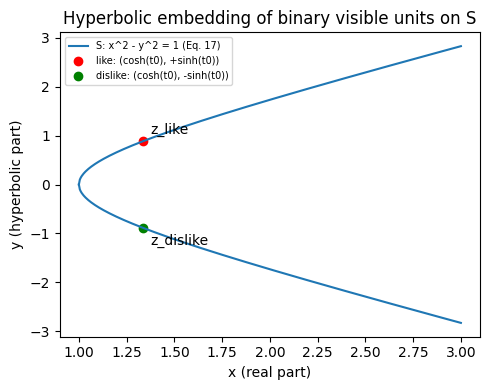

z_like = (x0, +y0): (1.3374349463048447, 0.888105982187623)
z_dislike = (x0, -y0): (1.3374349463048447, -0.888105982187623)


In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Plot the right branch of the unit hyperbola S (Eq. 17)
x0 = float(np.cosh(t0))
y0 = float(np.sinh(t0))

x = np.linspace(1.0, max(3.0, x0 * 1.2), 400)
y = np.sqrt(x**2 - 1.0)

plt.figure(figsize=(5, 4))
plt.plot(x, y, label="S: x^2 - y^2 = 1 (Eq. 17)")
plt.plot(x, -y, color="C0")

# Embedding points
plt.scatter([x0], [y0], color="red", label="like: (cosh(t0), +sinh(t0))")
plt.scatter([x0], [-y0], color="green", label="dislike: (cosh(t0), -sinh(t0))")
plt.annotate("z_like", (x0, y0), textcoords="offset points", xytext=(5, 5))
plt.annotate("z_dislike", (x0, -y0), textcoords="offset points", xytext=(5, -12))

plt.xlabel("x (real part)")
plt.ylabel("y (hyperbolic part)")
plt.title("Hyperbolic embedding of binary visible units on S")
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

print("z_like = (x0, +y0):", (x0, y0))
print("z_dislike = (x0, -y0):", (x0, -y0))
